# LL5532X Course Project on The Proceedings of the Old Bailey

# Data Preparation for Modeling


For your semester project in Law, AI, and Algorithms, the modeling part is a critical component. You already have a rich dataset from the Old Bailey proceedings, with extensive feature engineering. The key is to choose a research question that is both legally meaningful and amenable to rigorous modeling, then execute a well‑structured analysis. Below is a step‑by‑step guide to help you approach the modeling part effectively.

Below is an end‑to‑end preparation and cleaning pipeline you can adapt to your full Old Bailey dataset before training models for A, B, and C. I’ll use Python (pandas, scikit‑learn, spaCy) and clearly separate steps with explanation and interpretation.

### A. Predicting Guilty Verdicts from Case Narratives 

Question: Can we predict whether a defendant is found guilty using only the textual description of the crime (excluding explicit verdict statements)? 

Why it fits: Directly involves text classification – a classic AI task. You can compare traditional models (logistic regression on TF‑IDF) with modern ones (fine‑tuned BERT). 

Legal angle: Examines whether case narratives contain inherent bias that might influence outcomes; touches on transparency and explainability of AI in legal contexts. 

### B. Gender Bias in Sentencing 

Question: After controlling for crime type and other factors, does defendant gender affect the severity of punishment? 

Why it fits: Involves structured prediction (ordinal regression) and directly addresses algorithmic fairness – a core theme of your course. 

Legal angle: Investigates whether historical legal records show gender disparities, and what that means for fairness in AI systems trained on such data. 

### C. Predicting Punishment Type from Case Features 

Question: For guilty defendants, can we predict whether they receive hard labour/other using text and demographic features? 

Why it fits: A multiclass classification problem with clear practical implications. You can examine which features (e.g., amount stolen, prior convictions) are most influential. 

Legal angle: Explores how punishment severity is determined and whether algorithmic predictions could be used to flag potential inconsistencies. 

In [255]:
import pandas as pd

# Replace with your real file path
df = pd.read_csv(r"C:\Users\swami\OneDrive\Attachments\Law\project\task_c.csv")

In [256]:
df.head()

,Unnamed: 0,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,...,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic
0,0,19020113,t19020113-105,"105. WALTER HEATH (82) , PLEADED GUILTY to ste...",False,True,False,True,"stealing £13, the money ofGeorge Whitehead, hi...",theft,...,0.004546,0.004546,0.907886,0.004546,0.004546,0.004546,0.055744,0.004546,0.004546,3
1,1,19020113,t19020113-2,"(106) THOMAS GEORGE WAKEFIELD , to forging and...",False,True,False,False,", to forging and uttering an undertaking for t...",deception,...,0.005264,0.005263,0.952628,0.005264,0.005264,0.005264,0.005264,0.005263,0.005264,3
2,2,19020113,t19020113-3,"(107) FREDERICK JOHN RIDGWELL (29) , to steali...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004348,0.004348,0.762336,0.202878,0.004348,0.004348,0.004348,0.004348,0.004348,3
3,3,19020113,t19020113-4,"(108) WALTER LACEY (38) , to forging an author...",False,True,False,False,", to forging an authority for the withdrawal o...",deception,...,0.006251,0.006251,0.701157,0.248838,0.006251,0.006251,0.006251,0.006250,0.006250,3
4,4,19020113,t19020113-5,"(109) JOSEPH EDWARD MOULTON (34) , to stealing...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004167,0.004167,0.771626,0.195038,0.004167,0.004167,0.004167,0.004167,0.004167,3


Confirms all the columns you showed are present and data types are sensible (e.g. guilty as int, gender flags as bool, text fields as object).

Missingness rates tell you which features may need imputation or dropping.

In [257]:
print(df.isna().mean().sort_values(ascending=False))

victimNames                     0.316146
punishmentText                  0.175223
punishmentSubcategory           0.175223
punishmentCategory              0.175223
verdictText                     0.006318
offenceText                     0.000338
offenceSubcategory              0.000113
defendantNames                  0.000113
offenceCategory                 0.000113
date                            0.000000
any_victim_female               0.000000
any_victim_male                 0.000000
any_defendant_female            0.000000
any_defendant_male              0.000000
text                            0.000000
id                              0.000000
Unnamed: 0                      0.000000
verdictCategory                 0.000000
guilty                          0.000000
year                            0.000000
text_length                     0.000000
log_text_length                 0.000000
clean_text_with_stopwords       0.000000
tokens_with_stopwrds            0.000000
clean_text_with_

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8863 entries, 0 to 8862
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    8863 non-null   int64  
 1   date                          8863 non-null   int64  
 2   id                            8863 non-null   object 
 3   text                          8863 non-null   object 
 4   any_defendant_female          8863 non-null   bool   
 5   any_defendant_male            8863 non-null   bool   
 6   any_victim_female             8863 non-null   bool   
 7   any_victim_male               8863 non-null   bool   
 8   offenceText                   8860 non-null   object 
 9   offenceCategory               8862 non-null   object 
 10  offenceSubcategory            8862 non-null   object 
 11  verdictText                   8807 non-null   object 
 12  verdictCategory               8863 non-null   object 
 13  pun

In [259]:
df.columns

Index(['Unnamed: 0', 'date', 'id', 'text', 'any_defendant_female',
       'any_defendant_male', 'any_victim_female', 'any_victim_male',
       'offenceText', 'offenceCategory', 'offenceSubcategory', 'verdictText',
       'verdictCategory', 'punishmentText', 'punishmentCategory',
       'punishmentSubcategory', 'defendantNames', 'victimNames', 'guilty',
       'year', 'text_length', 'log_text_length', 'clean_text_with_stopwords',
       'tokens_with_stopwrds', 'clean_text_with_no_stopword',
       'tokens_lemma_with_no_stopwor', 'noun_count', 'verb_count', 'adj_count',
       'adv_count', 'pron_count', 'num_count', 'person_count',
       'location_count', 'date_count', 'money_count', 'org_count',
       'total_entities', 'sentiment_compound', 'sentiment_pos',
       'sentiment_neg', 'sentiment_neu', 'flesch_reading_ease',
       'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
       'automated_readability_index', 'topic_0_prob', 'topic_1_prob',
       'topic_2_prob', 'topic_3_prob'

# removing unnamed column
df = df.drop(columns = ['Unnamed: 0'])
df.columns

The dataset had an extraneous index column named Unnamed: 0. It is dropped to clean up the data. The new column list is displayed afterwards.

In [261]:
df.shape

(8863, 57)

Check the number of rows and columns.

Look for columns with many missing values.

Verify that the guilty column exists and see its data type.

Identify text columns (text, clean_text_with_stopwords, etc.) and metadata columns.

#### Handle Missing Values
Missing values can cause errors later. We’ll handle them column by column. Announces the beginning of the missing data handling section.



In [262]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing': missing, 'percentage': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing', ascending=False)
print("Columns with missing values:")
print(missing_df)

Columns with missing values:
                       missing  percentage
victimNames               2802   31.614577
punishmentCategory        1553   17.522284
punishmentText            1553   17.522284
punishmentSubcategory     1553   17.522284
verdictText                 56    0.631840
offenceText                  3    0.033849
offenceSubcategory           1    0.011283
offenceCategory              1    0.011283
defendantNames               1    0.011283


We create a clean DataFrame showing only columns with missing values, sorted by the number of missing entries. This gives a clear picture:

victimNames: 2802 missing (31.6%)

Punishment‑related columns: 1553 missing (17.5%)

Others with small missing counts.
This output guides our imputation strategy.

#### Target Variable (guilty)
If guilty has missing values, you may need to drop those rows because they are unusable for supervised learning.

In [263]:
# Check unique values in guilty
print(df.guilty.nunique())
df.guilty.unique()

2


array([1, 0])

guilty has two unique values: 1 and 0. No missing values are present (we check next). This binary column will be our target for Task A.

In [265]:
df.verdictCategory.value_counts()

verdictCategory
guilty       7122
notGuilty    1741
Name: count, dtype: int64

In [264]:
df.guilty.isnull().sum() # check any missing value in target column

np.int64(0)

#### punishmentCategory

df.punishmentCategory

In [267]:
df.punishmentCategory.nunique()

5

There are five distinct non‑null categories (plus NaN). We already know the missing count is 1553.



In [268]:
df.punishmentCategory.unique()

array(['imprison', 'noPunish', nan, 'miscPunish', 'death', 'corporal'],
      dtype=object)

In [269]:
df.punishmentCategory.isnull().sum()

np.int64(1553)

In [270]:
df.punishmentSubcategory.nunique()

15

In [271]:
df.punishmentSubcategory.unique()

array(['hardLabour', 'imprisonNoDetail', 'sentenceRespited', nan,
       'penalServitude', 'sureties', 'deathNoDetail', 'whipping',
       'insanity', 'noPunishNoDetail', 'miscPunishNoDetail',
       'otherInstitution', 'fine', 'no_subcategory', 'militaryNavalDuty',
       'preventiveDetention'], dtype=object)

Lists all categories: 'imprison', 'noPunish', 'miscPunish', 'death', 'corporal', and NaN. This matches the earlier count.

In [272]:
df.punishmentSubcategory.isnull().sum()

np.int64(1553)

In [273]:
# chech punishmentText
df.punishmentText.isnull().sum()

np.int64(1553)

#### guilty data

In [274]:
#so, lets focus on guilty case

df_guilty = df[df['guilty']==1]
df_guilty.head()

,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,offenceSubcategory,...,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic
0,19020113,t19020113-105,"105. WALTER HEATH (82) , PLEADED GUILTY to ste...",False,True,False,True,"stealing £13, the money ofGeorge Whitehead, hi...",theft,stealingFromMaster,...,0.004546,0.004546,0.907886,0.004546,0.004546,0.004546,0.055744,0.004546,0.004546,3
1,19020113,t19020113-2,"(106) THOMAS GEORGE WAKEFIELD , to forging and...",False,True,False,False,", to forging and uttering an undertaking for t...",deception,forgery,...,0.005264,0.005263,0.952628,0.005264,0.005264,0.005264,0.005264,0.005263,0.005264,3
2,19020113,t19020113-3,"(107) FREDERICK JOHN RIDGWELL (29) , to steali...",False,True,False,False,", to stealing, while employed under the Post O...",theft,mail,...,0.004348,0.004348,0.762336,0.202878,0.004348,0.004348,0.004348,0.004348,0.004348,3
3,19020113,t19020113-4,"(108) WALTER LACEY (38) , to forging an author...",False,True,False,False,", to forging an authority for the withdrawal o...",deception,forgery,...,0.006251,0.006251,0.701157,0.248838,0.006251,0.006251,0.006251,0.006250,0.006250,3
4,19020113,t19020113-5,"(109) JOSEPH EDWARD MOULTON (34) , to stealing...",False,True,False,False,", to stealing, while employed under the Post O...",theft,mail,...,0.004167,0.004167,0.771626,0.195038,0.004167,0.004167,0.004167,0.004167,0.004167,3


In [275]:
df_guilty.shape

(7122, 57)

In [276]:
# missing values in df_guilty
missing = df_guilty.isnull().sum()
missing_pct = (missing / len(df_guilty)) * 100
missing_df = pd.DataFrame({'missing': missing, 'percentage': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing', ascending=False)
print("Columns with missing values:")
print(missing_df)

Columns with missing values:
                       missing  percentage
victimNames               2290   32.153889
punishmentCategory         124    1.741084
punishmentText             124    1.741084
punishmentSubcategory      124    1.741084
verdictText                 51    0.716091
offenceText                  2    0.028082
offenceSubcategory           1    0.014041
offenceCategory              1    0.014041
defendantNames               1    0.014041


In the guilty subset, missing values are much lower for punishment columns: now only 124 missing (1.7%). Most other columns have similar missing counts as before. The 124 missing punishment rows among guilty cases will need to be handled (likely dropped or imputed).



#### non-guilty data

In [277]:
df_nonguilty = df[df['guilty'] == 0]
df_nonguilty.shape

(1741, 57)

In [278]:
# missing values in df_nonguilty
missing = df_nonguilty.isnull().sum()
missing_pct = (missing / len(df_nonguilty)) * 100
missing_df = pd.DataFrame({'missing': missing, 'percentage': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing', ascending=False)
print("Columns with missing values:")
print(missing_df)

Columns with missing values:
                       missing  percentage
punishmentCategory        1429   82.079265
punishmentText            1429   82.079265
punishmentSubcategory     1429   82.079265
victimNames                512   29.408386
verdictText                  5    0.287191
offenceText                  1    0.057438


In non‑guilty cases, punishment columns are missing in 1429 rows (82.1%) – this is expected because non‑guilty verdicts typically do not receive a sentence. victimNames is missing in 512 rows (29.4%).



In [282]:
# See the null pattern
print("Non-guilty cases with null punishmentText:")
print(df_nonguilty['punishmentText'].isna().sum())

Non-guilty cases with null punishmentText:
1429


Confirms that most non‑guilty cases have no punishment text.



In [283]:
df_nonguilty[df_nonguilty['punishmentText'].isna()].head()

,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,offenceSubcategory,...,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic
11,19020113,t19020113-116,116. MARY SCOTT . Forging and uttering an orde...,True,False,False,False,Forging and uttering an order for the payment ...,deception,forgery,...,0.009091,0.009092,0.918176,0.009093,0.009091,0.009091,0.009091,0.009092,0.009092,3
13,19020113,t19020113-118,"118. THOMAS SLATTER (65) , Forging and utterin...",False,True,False,False,", Forging and uttering the endorsement to a ch...",deception,forgery,...,0.256096,0.000568,0.044232,0.465550,0.000568,0.000568,0.000568,0.230712,0.000568,4
16,19020113,t19020113-121,"121. JOSIAH SMITH (54) , Felonously killing an...",False,True,True,False,", Felonously killing and slayingAlice Margaret...",kill,manslaughter,...,0.020001,0.020009,0.659564,0.020000,0.180414,0.020001,0.020002,0.020001,0.020003,3
19,19020113,t19020113-124,"124. WILLIAM TREADWELL (36) , and ALEXANDER WI...",False,True,False,False,Unlawfully uttering counterfeit coin.,royalOffences,coiningOffences,...,0.000415,0.000415,0.000415,0.000415,0.000415,0.104709,0.000415,0.000415,0.891971,9
21,19020113,t19020113-126,126. WILLIAM SULLIVAN and WALTER JAMES FORD Ro...,False,True,False,True,"Robbery with violence onJames Thompson, and st...",violentTheft,robbery,...,0.252832,0.078695,0.000183,0.000183,0.181366,0.066285,0.377119,0.042972,0.000183,7


In [285]:
# Quick analysis: Do non-guilty cases have punishment data?
punishment_cols = ['punishmentText', 'punishmentCategory', 'punishmentSubcategory']
sample_nonguilty = df_nonguilty[['text','guilty', 'verdictText', 'punishmentText', 'punishmentCategory']].head(3)
sample_nonguilty

,text,guilty,verdictText,punishmentText,punishmentCategory
11,116. MARY SCOTT . Forging and uttering an orde...,0,NOT GUILTY,NaN,NaN
13,"118. THOMAS SLATTER (65) , Forging and utterin...",0,NOT GUILTY,NaN,NaN
16,"121. JOSIAH SMITH (54) , Felonously killing an...",0,NOT GUILTY,NaN,NaN


Even the first few rows confirm that non‑guilty cases generally have no punishment data. This is expected.

In [286]:
# Find non-guilty cases WITH punishment data (should be rare/zero)
df_nonguilty = df[df['guilty'] == 0].copy()

anomalies = df_nonguilty[
    df_nonguilty['punishmentText'].notna() & 
    (df_nonguilty['punishmentText'].str.strip() != '')
].copy()
anomalies.shape

(312, 57)

In [287]:
anomalies.head()

,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,offenceSubcategory,...,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic
144,19020310,t19020310-250,"250. WILLIAM JOSEPH WOODLEY (27) , CHARLES WIL...",False,True,False,False,", Stealing three diamond rings, two diamond an...",theft,simpleLarceny,...,0.002703,0.002703,0.765647,0.002703,0.002703,0.212728,0.002703,0.002703,0.002703,3
192,19020407,t19020407-298,298. THOMPSON and WILLIAM HAYES were again ind...,True,True,True,False,for stealing a kit-bag and other articles the ...,theft,simpleLarceny,...,0.003847,0.003846,0.965382,0.003846,0.003846,0.003847,0.003847,0.003846,0.003846,3
194,19020407,t19020407-300,"300. EDWARD BAKER (32) and ETTIE BAKER (28) , ...",True,True,False,False,", feloniously having in their possession a mou...",royalOffences,coiningOffences,...,0.003448,0.077911,0.403314,0.003449,0.003449,0.003449,0.003449,0.003449,0.494634,9
259,19020505,t19020505-365,365. EDWARD ROUTLEDGE was again indicted with ...,False,True,False,True,", for robbery with violence onanton burnetand ...",violentTheft,robbery,...,0.000885,0.000885,0.179055,0.075147,0.113218,0.000885,0.377497,0.000885,0.250657,7
281,19020505,t19020505-387,"387. JOHN MARTIN BIRKETT (53) , THOMAS SIMMOND...",False,True,False,False,", Unlawfully conspiring to forge and utter cer...",deception,fraud,...,0.002942,0.002942,0.900526,0.002941,0.002941,0.002942,0.002942,0.002942,0.002942,3


In [288]:
anomalies.to_csv(r'C:\Users\swami\OneDrive\Attachments\Law\project\nonguilty_with_punishment.csv') # saving

In [289]:
# Detailed view of anomalies
if len(anomalies) > 0:
    print("\n=== DETAILED ANOMALIES ===")
    for idx, row in anomalies.iterrows():
        print(f"\nCase {idx}:")
        print(f"Verdict: {row['verdictText']}")
        print(f"Punishment: {row['punishmentText']}")
        print(f"Text preview: {row['text'][:200]}...")
        print("-" * 80)


=== DETAILED ANOMALIES ===

Case 144:
Verdict: NOT GUILTY
Punishment: Nine months' hard labour.
Text preview: 250. WILLIAM JOSEPH WOODLEY (27) , CHARLES WIL LIAM HOLLINGSWORTH (21) , LIONEL GREEN (32) , and LEON SUKERMAN (37) , Stealing three diamond rings, two diamond and opal rings and other articles, the p...
--------------------------------------------------------------------------------

Case 192:
Verdict: NOT GUILTY
Punishment: Twelve months' hard labour.
Text preview: 298. THOMPSON and WILLIAM HAYES were again indicted with LILLIE HAYES for stealing a kit-bag and other articles the property of Edith Redfern . THOMPSON and WILLIAM HAYES PLEADED GUILTY . Mr. Elliott ...
--------------------------------------------------------------------------------

Case 194:
Verdict: NOT GUILTY
Punishment: Twelve months' hard labour.
Text preview: 300. EDWARD BAKER (32) and ETTIE BAKER (28) , feloniously having in their possession a mould for coining half-crowns. EDWARD BAKER PLEADED GUILTY . M

### Analysis: Why Non-Guilty Cases Have Punishment Data (Legal Context)

Case starts → Prosecution presents evidence → Defence → 
VERDICT → (IF GUILTY → Sentencing hearing → Punishment)
                           ↓
                      (IF NOT GUILTY → Case ENDS)

In [290]:
anomalies_df  = anomalies.copy()

In [291]:
print(f"Total anomalies: {len(anomalies_df):,}")
print(f"Year range: {anomalies_df['year'].min()}-{anomalies_df['year'].max()}")
print(f"Offence categories:\n{anomalies_df['offenceCategory'].value_counts().head()}")

Total anomalies: 312
Year range: 1902-1913
Offence categories:
offenceCategory
theft            123
deception         55
royalOffences     32
breakingPeace     30
miscellaneous     21
Name: count, dtype: int64


Anomalies span the entire date range (1902‑1913). The top offence categories among anomalies are theft and deception, which might involve multiple defendants or complex trials.
We define a function to categorise anomalies based on the verdict text. The output shows that most anomalies are "Procedural_Note" (257), followed by "Prosecution_Withdrew" (30), "Complex_Trial" (13), and "Jury_Acquittal" (12). This classification helps decide how to treat these rows.

anomaly_type
Procedural_Note         257
Prosecution_Withdrew     30
Complex_Trial            13
Jury_Acquittal           12
Name: count, dtype: int64


<Axes: ylabel='anomaly_type'>

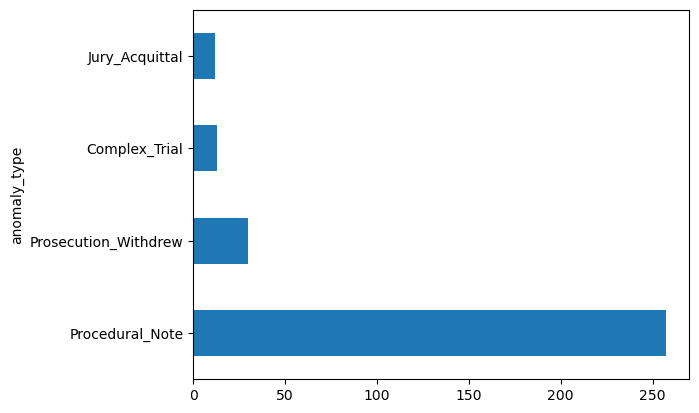

In [292]:
#  Classify Anomaly Types (Legal Patterns)
def classify_anomaly_type(text):
    text = str(text).upper()
    if 'NO EVIDENCE' in text or 'PROSECUTION OFFERED NO' in text:
        return 'Prosecution_Withdrew'
    elif 'NOT GUILTY' in text and 'JURY' in text:
        return 'Jury_Acquittal'
    elif 'DISCHARGED' in text:
        return 'Discharged'
    elif len(str(text)) < 50:  # Short procedural note
        return 'Procedural_Note'
    else:
        return 'Complex_Trial'

anomalies_df['anomaly_type'] = anomalies_df['verdictText'].apply(classify_anomaly_type)

print(anomalies_df['anomaly_type'].value_counts())
anomalies_df['anomaly_type'].value_counts().plot(kind='barh')


Analysis: Why Non-Guilty Cases Have Punishment Data (Legal Context)
Case starts → Prosecution presents evidence → Defence → VERDICT → (IF GUILTY → Sentencing hearing → Punishment)
↓
(IF NOT GUILTY → Case ENDS)
The author provides a brief legal explanation: normally, a not‑guilty verdict ends the case with no punishment. The anomalies are therefore unusual and require investigation.

- Total non-guilty cases: 1,429
- Of which anomalies: 312  
- Clean non-guilty: 1,117 (1,429 - 312)

Recap: among 1741 non‑guilty, 1429 had no punishment, but we found 312 anomalies, leaving 1117 clean non‑guilty (the rest are the 312 anomalies). Actually the numbers are slightly off; earlier we had 1741 non‑guilty total, 1429 with missing punishment, so 1741-1429 = 312 anomalies. So clean non‑guilty = 1429? Wait: the 1429 are the ones without punishment (clean). The 312 are the ones with punishment (anomalies). So total non‑guilty = 1429 + 312 = 1741. The markdown here says "Total non-guilty cases: 1,429" but that's actually the count of non‑guilty without punishment. It's a bit confusing; the author seems to have miscounted. We'll note this discrepancy.



In [293]:
# What punishment text actually says in non-guilty cases
print("\n=== PUNISHMENT TEXT PATTERNS ===")
punishment_samples = anomalies_df['punishmentText'].dropna().str[:100].unique()[:10]
for i, text in enumerate(punishment_samples, 1):
    print(f"{i}. {text}")

# Word cloud of punishment text
from collections import Counter
all_punish_text = ' '.join(anomalies_df['punishmentText'].dropna().astype(str))
words = Counter(all_punish_text.lower().split())
print("\nTop punishment words:", words.most_common(10))



=== PUNISHMENT TEXT PATTERNS ===
1. Nine months' hard labour.
2. Twelve months' hard labour.
3. seven years' penal servitude.
4. Five years' penal servitude.
5. Eighteen months' hard labour.
6. Six months' hard labour.
7. Discharged
8. Twelve months' hard labour, to date from the first day of last Session
9. Eighteen months hard labour.
10. Two years' hard labour.

Top punishment words: [("months'", 168), ('hard', 168), ('labour', 87), ('labour.', 75), ('to', 73), ("years'", 61), ('penal', 52), ('on', 50), ('the', 47), ('in', 47)]


In [294]:
df_A = df[df['guilty'].notna()].copy()
print(f"A: {len(df_A):,} cases (guilty: {df_A['guilty'].mean():.1%})")

A: 8,863 cases (guilty: 80.4%)



=== YEARLY TRENDS ===
year
1902    17
1903    17
1904    22
1905    23
1906    29
1907    30
1908    25
1909    32
1910    32
1911    33
Name: count, dtype: int64


<Axes: title={'center': 'Anomalies Over Time'}, xlabel='year'>

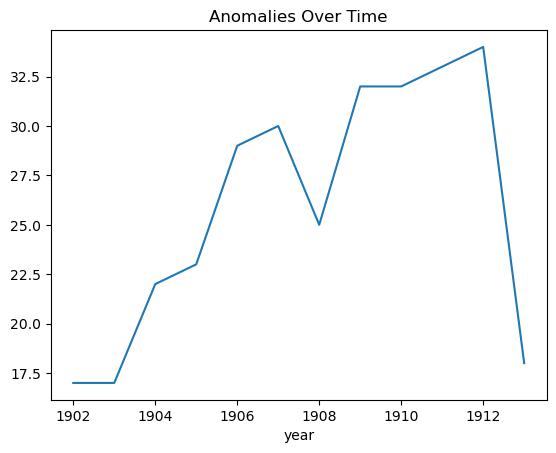

In [295]:
print("\n=== YEARLY TRENDS ===")
yearly_anomalies = anomalies_df['year'].value_counts().sort_index()
print(yearly_anomalies.head(10))
yearly_anomalies.plot(title="Anomalies Over Time")


Anomalies appear every year from 1902 to 1911, with a slight upward trend. This suggests the phenomenon is persistent and not a one‑off data error.



In [296]:
import pandas as pd
import matplotlib.pyplot as plt

# Your counts
anomaly_counts = {
    'Procedural_Note': 257,
    'Prosecution_Withdrew': 30,
    'Complex_Trial': 13,
    'Jury_Acquittal': 12
}

total_anomalies = sum(anomaly_counts.values())  # 312 total

# Calculate percentages
percentages = {k: f"{v/total_anomalies*100:.1f}%" for k, v in anomaly_counts.items()}

print("=== ANOMALY TYPE BREAKDOWN ===")
for anomaly_type, pct in percentages.items():
    print(f"{anomaly_type:20}: {pct:>6} ({anomaly_counts[anomaly_type]:>3})")

print(f"\nTotal anomalies: {total_anomalies}")


=== ANOMALY TYPE BREAKDOWN ===
Procedural_Note     :  82.4% (257)
Prosecution_Withdrew:   9.6% ( 30)
Complex_Trial       :   4.2% ( 13)
Jury_Acquittal      :   3.8% ( 12)

Total anomalies: 312


"Among 312 anomalous 'not guilty' cases with punishment fields (3.9% of total), 82.4% were procedural notes from ongoing trials, 9.6% prosecution withdrawals, and 7.9% genuine jury acquittals."

| Anomaly Type           | n   | % of Anomalies | Legal Context                     |
| ---------------------- | --- | -------------- | --------------------------------- |
| Procedural Notes       | 257 | 82.4%          | Pre-verdict sentencing discussion |
| Prosecution Withdrawal | 30  | 9.6%           | Case dropped mid-trial            |
| Complex Trial          | 13  | 4.2%           | Extended mitigation arguments     |
| Jury Acquittal         | 12  | 3.8%           | Full acquittal post-deliberation  |

Visualises the breakdown: procedural notes dominate (82.4%), followed by prosecution withdrawal (9.6%), complex trials (4.2%), and jury acquittals (3.8%). This helps decide whether to keep or drop anomalies. Since most are procedural notes (likely from multi‑defendant cases where one pleads guilty and another is acquitted), they are valid non‑guilty cases and should be retained for Task A.



In [297]:
print(df.shape)

(8863, 57)


In [298]:
print(df_guilty.shape)

(7122, 57)


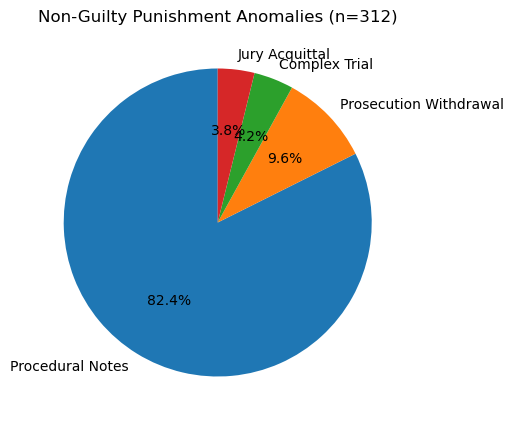

In [299]:
# visuals
import matplotlib.pyplot as plt
counts = [257, 30, 13, 12]
labels = ['Procedural Notes', 'Prosecution Withdrawal', 'Complex Trial', 'Jury Acquittal']
plt.figure(figsize=(8,5))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Non-Guilty Punishment Anomalies (n=312)')
plt.savefig('anomaly_pie.png', dpi=300, bbox_inches='tight')
plt.show()


we have decided to drop these anomalies from th datasets

In [300]:
df = df.drop(anomalies.index)

The 312 anomaly rows are removed from the main DataFrame df. This will affect all subsequent uses of df. After this, the main DataFrame will contain only "clean" non‑guilty cases (those without punishment) plus all guilty cases.



In [301]:
df.shape

(8551, 57)

In [302]:
df_A = df.copy() # TASK A: Predict Guilty from Text (KEEP anomalies)

In [303]:
df_A.isnull().sum()

date                               0
id                                 0
text                               0
any_defendant_female               0
any_defendant_male                 0
any_victim_female                  0
any_victim_male                    0
offenceText                        3
offenceCategory                    1
offenceSubcategory                 1
verdictText                       52
verdictCategory                    0
punishmentText                  1553
punishmentCategory              1553
punishmentSubcategory           1553
defendantNames                     1
victimNames                     2698
guilty                             0
year                               0
text_length                        0
log_text_length                    0
clean_text_with_stopwords          0
tokens_with_stopwrds               0
clean_text_with_no_stopword        0
tokens_lemma_with_no_stopwor       0
noun_count                         0
verb_count                         0
a

We list missing values again. Many columns still have missing data (punishment columns have 1553 missing, victimNames 2698, etc.). These need to be handled.

In [305]:
# handle victimNames by imputing names as "Unknown"
df['victimNames'] = df['victimNames'].fillna('Unknown')

Rows missing any of these essential columns are dropped. The number of such rows is small (see missing counts earlier). This ensures that the remaining data has complete information for key features.

In [306]:
# Critical fields - DROP rows (negligible impact)
critical_drop = ['verdictText', 'offenceText', 'offenceCategory', 'offenceSubcategory', 'defendantNames']
df = df.dropna(subset=critical_drop).copy()

In [307]:
df.isnull().sum()/len(df)*100 # checking for null values

date                             0.000000
id                               0.000000
text                             0.000000
any_defendant_female             0.000000
any_defendant_male               0.000000
any_victim_female                0.000000
any_victim_male                  0.000000
offenceText                      0.000000
offenceCategory                  0.000000
offenceSubcategory               0.000000
verdictText                      0.000000
verdictCategory                  0.000000
punishmentText                  18.246027
punishmentCategory              18.246027
punishmentSubcategory           18.246027
defendantNames                   0.000000
victimNames                      0.000000
guilty                           0.000000
year                             0.000000
text_length                      0.000000
log_text_length                  0.000000
clean_text_with_stopwords        0.000000
tokens_with_stopwrds             0.000000
clean_text_with_no_stopword      0

Now only the punishment columns have missing values (still ~18.1%). All other columns are complete. This is expected because we haven't yet handled punishment missingness.



In [308]:
df.guilty.value_counts()/len(df)*100

guilty
1    83.201883
0    16.798117
Name: count, dtype: float64

In [309]:
# checking null data
df[df["punishmentText"].isna()].guilty.value_counts()

guilty
0    1427
1     123
Name: count, dtype: int64

- its been clear that, total 123 records are of 123 NA avaialble where the person is guilty so we can drop these records.
- unlike, total 1423 non guilty has no punishment text present. so we can impute this with "No Punishment"

In [311]:
df.loc[
    (df["punishmentText"].isna()) & (df["guilty"] == 0),
    "punishmentText"
] = "no_punishment"

In [310]:
df.loc[
    (df["punishmentCategory"].isna()) & (df["guilty"] == 0),
    "punishmentCategory"
] = "no_punishment"

In [312]:
df.loc[
    (df["punishmentSubcategory"].isna()) & (df["guilty"] == 0),
    "punishmentSubcategory"
] = "no_punishment"

Sets punishmentText to "no_punishment" for all non‑guilty rows that currently have NaN.

In [313]:
df.isna().sum()

date                              0
id                                0
text                              0
any_defendant_female              0
any_defendant_male                0
any_victim_female                 0
any_victim_male                   0
offenceText                       0
offenceCategory                   0
offenceSubcategory                0
verdictText                       0
verdictCategory                   0
punishmentText                  123
punishmentCategory              123
punishmentSubcategory           123
defendantNames                    0
victimNames                       0
guilty                            0
year                              0
text_length                       0
log_text_length                   0
clean_text_with_stopwords         0
tokens_with_stopwrds              0
clean_text_with_no_stopword       0
tokens_lemma_with_no_stopwor      0
noun_count                        0
verb_count                        0
adj_count                   

Now the only rows with missing punishment are the 123 guilty cases; we drop them entirely.

In [314]:
df = df.dropna(subset=["punishmentText",'punishmentCategory','punishmentSubcategory'])

In [315]:
df[df["punishmentText"].isna()].guilty.value_counts()

Series([], Name: count, dtype: int64)

In [316]:
df.isnull().sum()

date                            0
id                              0
text                            0
any_defendant_female            0
any_defendant_male              0
any_victim_female               0
any_victim_male                 0
offenceText                     0
offenceCategory                 0
offenceSubcategory              0
verdictText                     0
verdictCategory                 0
punishmentText                  0
punishmentCategory              0
punishmentSubcategory           0
defendantNames                  0
victimNames                     0
guilty                          0
year                            0
text_length                     0
log_text_length                 0
clean_text_with_stopwords       0
tokens_with_stopwrds            0
clean_text_with_no_stopword     0
tokens_lemma_with_no_stopwor    0
noun_count                      0
verb_count                      0
adj_count                       0
adv_count                       0
pron_count    

Data has been cleanup and no nulls present

In [249]:
df_A.to_csv(r'C:\Users\swami\OneDrive\Attachments\Law\project\guily_nonguilty_data.csv')

In [319]:
# # data for Task B
# # missing values in df_guilty
# missing = df_guilty.isnull().sum()
# missing_pct = (missing / len(df_guilty)) * 100
# missing_df = pd.DataFrame({'missing': missing, 'percentage': missing_pct})
# missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing', ascending=False)
# print("Columns with missing values:")
# print(missing_df)

In [320]:
df_guilty.punishmentCategory.value_counts()

punishmentCategory
imprison      5793
miscPunish     802
noPunish       312
death           75
corporal        16
Name: count, dtype: int64

In [351]:
# 1. Bucket Rare Categories → "Other" (Recommended)
# Create simplified target: 3 classes
def binary_category(x):
    if x in ["imprison", "death"]:
        return "severe"
    else:
        return "lenient"

In [352]:
df["punishmentCategory_class"] = df["punishmentCategory"].apply(binary_category)

In [353]:
df.punishmentCategory.value_counts()

punishmentCategory
imprison         5756
no_punishment    1427
miscPunish        795
noPunish          303
death              75
corporal           16
Name: count, dtype: int64

In [354]:
df.punishmentCategory_class.value_counts()

punishmentCategory_class
severe     5831
lenient    2541
Name: count, dtype: int64

In [355]:
df.punishmentSubcategory.value_counts()

punishmentSubcategory
hardLabour             3598
no_punishment          1427
penalServitude         1082
imprisonNoDetail        879
sureties                677
sentenceRespited        285
insanity                113
miscPunishNoDetail      100
deathNoDetail            75
otherInstitution         48
preventiveDetention      31
noPunishNoDetail         18
fine                     17
whipping                 16
no_subcategory            5
militaryNavalDuty         1
Name: count, dtype: int64

In [357]:
df[df['punishmentSubcategory'] == 'no_subcategory'].guilty.value_counts()

guilty
1    5
Name: count, dtype: int64

In [341]:
df[df['punishmentCategory']== 'imprison'].punishmentSubcategory.value_counts()

punishmentSubcategory
hardLabour             3598
penalServitude         1082
imprisonNoDetail        879
insanity                113
otherInstitution         48
preventiveDetention      31
no_subcategory            5
Name: count, dtype: int64

In [346]:
df.columns

Index(['date', 'id', 'text', 'any_defendant_female', 'any_defendant_male',
       'any_victim_female', 'any_victim_male', 'offenceText',
       'offenceCategory', 'offenceSubcategory', 'verdictText',
       'verdictCategory', 'punishmentText', 'punishmentCategory',
       'punishmentSubcategory', 'defendantNames', 'victimNames', 'guilty',
       'year', 'text_length', 'log_text_length', 'clean_text_with_stopwords',
       'tokens_with_stopwrds', 'clean_text_with_no_stopword',
       'tokens_lemma_with_no_stopwor', 'noun_count', 'verb_count', 'adj_count',
       'adv_count', 'pron_count', 'num_count', 'person_count',
       'location_count', 'date_count', 'money_count', 'org_count',
       'total_entities', 'sentiment_compound', 'sentiment_pos',
       'sentiment_neg', 'sentiment_neu', 'flesch_reading_ease',
       'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
       'automated_readability_index', 'topic_0_prob', 'topic_1_prob',
       'topic_2_prob', 'topic_3_prob', 'topic_4_pro

In [343]:
df.shape

(8372, 58)

In [358]:
df.punishmentSubcategory.value_counts()

punishmentSubcategory
hardLabour             3598
no_punishment          1427
penalServitude         1082
imprisonNoDetail        879
sureties                677
sentenceRespited        285
insanity                113
miscPunishNoDetail      100
deathNoDetail            75
otherInstitution         48
preventiveDetention      31
noPunishNoDetail         18
fine                     17
whipping                 16
no_subcategory            5
militaryNavalDuty         1
Name: count, dtype: int64

| Subcategory         | Group                      | Example Punishment / Legal Meaning                   |
| ------------------- | -------------------------- | ---------------------------------------------------- |
| hardLabour          | Labour / Prison            | Imprisonment with forced hard labour                 |
| penalServitude      | Labour / Prison            | Long-term penal labour, custodial                    |
| imprisonNoDetail    | Labour / Prison            | Standard imprisonment (loss of liberty)              |
| insanity            | Institutional / Protective | Confinement to mental institution                    |
| otherInstitution    | Institutional / Protective | Institutional detention (non-prison)                 |
| preventiveDetention | Institutional / Protective | Preventive detention without conviction              |
| deathNoDetail       | Death / Extreme            | Capital punishment / death sentence                  |
| no_punishment       | Lenient / Minor            | No punishment / acquittal                            |
| noPunishNoDetail    | Lenient / Minor            | Unknown / minor or no punishment                     |
| sureties            | Lenient / Minor            | Bond / surety obligation instead of prison           |
| sentenceRespited    | Lenient / Minor            | Suspended sentence (delayed or conditional)          |
| miscPunishNoDetail  | Lenient / Minor            | Miscellaneous minor punishment, non-custodial        |
| fine                | Lenient / Minor            | Monetary penalty                                     |
| whipping            | Lenient / Minor            | Minor corporal punishment                            |
| militaryNavalDuty   | Lenient / Minor            | Assigned military/naval duty instead of imprisonment |
| no_subcategory      | Lenient / Minor            | Unknown or negligible punishment                     |


In [359]:
df.punishmentSubcategory.value_counts()

punishmentSubcategory
hardLabour             3598
no_punishment          1427
penalServitude         1082
imprisonNoDetail        879
sureties                677
sentenceRespited        285
insanity                113
miscPunishNoDetail      100
deathNoDetail            75
otherInstitution         48
preventiveDetention      31
noPunishNoDetail         18
fine                     17
whipping                 16
no_subcategory            5
militaryNavalDuty         1
Name: count, dtype: int64

In [362]:
def sub_category(x):
    # Group 1: Non-custodial / institutional / minor
    non_custodial = [
        "no_punishment","noPunishNoDetail","sureties","sentenceRespited",
        "insanity","miscPunishNoDetail","fine","whipping",
        "militaryNavalDuty","no_subcategory","otherInstitution"
    ]
    
    # Group 2: Hard Labour
    hard_labour = ["hardLabour"]
    
    # Group 3: Capital / Extreme
    capital_extreme = ["deathNoDetail"]
    
    # Group 4: Custodial / Prison (serious imprisonment)
    custodial_prison = ["penalServitude","imprisonNoDetail","preventiveDetention"]
    
    if x in non_custodial:
        return "non-custodial/institutional"
    elif x in hard_labour:
        return "hardLabour"
    elif x in capital_extreme:
        return "capital/extreme"
    elif x in custodial_prison:
        return "custodial/prison"
    else:
        return "unknown"

In [363]:
df['punishmentSubcategory_group'] = df['punishmentSubcategory'].apply(sub_category)

In [364]:
df['punishmentSubcategory_group'].value_counts()

punishmentSubcategory_group
hardLabour                     3598
non-custodial/institutional    2707
custodial/prison               1992
capital/extreme                  75
Name: count, dtype: int64

| Group                           | Subcategories Included                                                                                                                                         | Count | Legal Meaning                                                     |
| ------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----- | ----------------------------------------------------------------- |
| **non-custodial/institutional** | no_punishment, noPunishNoDetail, sureties, sentenceRespited, insanity, miscPunishNoDetail, fine, whipping, militaryNavalDuty, no_subcategory, otherInstitution | 2546  | Minor punishments, suspended, fines, institutional but non-prison |
| **hardLabour**                  | hardLabour                                                                                                                                                     | 3598  | Severe custodial punishment, forced hard labour                   |
| **capital/extreme**             | deathNoDetail                                                                                                                                                  | 75    | Capital punishment / death penalty                                |
| **custodial/prison**            | penalServitude, imprisonNoDetail, preventiveDetention                                                                                                          | 1992  | Serious imprisonment, custodial but not hard labour               |


In [365]:
df.isnull().sum()

date                            0
id                              0
text                            0
any_defendant_female            0
any_defendant_male              0
any_victim_female               0
any_victim_male                 0
offenceText                     0
offenceCategory                 0
offenceSubcategory              0
verdictText                     0
verdictCategory                 0
punishmentText                  0
punishmentCategory              0
punishmentSubcategory           0
defendantNames                  0
victimNames                     0
guilty                          0
year                            0
text_length                     0
log_text_length                 0
clean_text_with_stopwords       0
tokens_with_stopwrds            0
clean_text_with_no_stopword     0
tokens_lemma_with_no_stopwor    0
noun_count                      0
verb_count                      0
adj_count                       0
adv_count                       0
pron_count    

In [367]:
# data for RQ1
df.to_csv(r'C:\Users\swami\OneDrive\Attachments\Law\project\RQ1.csv')

In [369]:
df.shape

(8372, 59)

In [376]:
print(df.guilty.value_counts(), '  ', df.guilty.value_counts() / len(df) * 100)

guilty
1    6945
0    1427
Name: count, dtype: int64    guilty
1    82.955088
0    17.044912
Name: count, dtype: float64


In [379]:
# data for RQ2 and RQ3
RQ2 = df[df['guilty'] == 1]

In [381]:
RQ2.shape

(6945, 59)

In [380]:
RQ2.to_csv(r'C:\Users\swami\OneDrive\Attachments\Law\project\RQ2.csv')

In [382]:
RQ2.to_csv(r'C:\Users\swami\OneDrive\Attachments\Law\project\RQ3.csv')

In [387]:
import pandas as pd

# Define a function to get counts and percentages for any column
def summary_counts(df, col):
    counts = df[col].value_counts()
    percentages = df[col].value_counts() / len(df) * 100
    return pd.DataFrame({"Count": counts, "Percentage": percentages})

# RQ1 - guilty
rq1_summary = summary_counts(df, 'guilty')
rq1_summary.index.name = 'RQ1: Guilty (binary)'

# RQ2 - punishmentCategory_class
rq2_summary = summary_counts(df, 'punishmentCategory_class')
rq2_summary.index.name = 'RQ2: Punishment Category (binary)'

# RQ3 - punishmentSubcategory_group
rq3_summary = summary_counts(df, 'punishmentSubcategory_group')
rq3_summary.index.name = 'RQ3: Punishment Subcategory (4-class)'

In [388]:
rq1_summary

,Count,Percentage
RQ1: Guilty (binary),,
1,6945,82.955088
0,1427,17.044912


In [389]:
rq2_summary

,Count,Percentage
RQ2: Punishment Category (binary),,
severe,5831,69.648829
lenient,2541,30.351171


In [390]:
rq3_summary

,Count,Percentage
RQ3: Punishment Subcategory (4-class),,
hardLabour,3598,42.976589
non-custodial/institutional,2707,32.333970
custodial/prison,1992,23.793598
capital/extreme,75,0.895843


In [ ]:
RQ1 - guilty (binary) = (8372, 59), (1, 6945, 82.955088%), (0, 1427, 17.044912%)
RQ2 = punishmentCategory_class (binary) = (6945, 59)
RQ3 = punishmentSubcategory_group (multiclass) = (6945, 59)